# 03 XAI-Erklärungen und Modellvergleich

Die XAI-Auswertung wird für alle vier finalen Modelle durchgeführt. Verwendet werden dieselben Merkmale und derselbe Testsplit wie im Modelltraining.

## Vorbereitung

Benötigte Bibliotheken werden geladen. Die Zertifikate für den Abruf des UCI-Datensatzes werden eingerichtet. Der Zufallswert wird für reproduzierbare Ergebnisse festgelegt.

In [1]:
import os
import ssl
import urllib.request
import warnings

warnings.filterwarnings('ignore', message='IProgress not found.*')

import certifi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
MODEL_ORDER = ['Logistic Regression', 'Random Forest', 'HistGradientBoosting', 'MLP Neural Network']



## Daten und Testsplit

Der Datensatz wird geladen und auf Größe, Klassen und fehlende Werte geprüft. Anschließend werden die acht finalen Merkmale ausgewählt. Der Split entspricht dem Modelltraining.

In [2]:
data_url = 'https://archive.ics.uci.edu/static/public/602/data.csv'
with urllib.request.urlopen(data_url, context=ssl.create_default_context(cafile=certifi.where())) as response:
    df_all = pd.read_csv(response)

X_all = df_all.drop(columns=['Class'])
y = df_all['Class']
expected_classes = {'SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SIRA'}
assert X_all.shape == (13611, 16)
assert set(y.unique()) == expected_classes
assert X_all.isna().sum().sum() == 0 and y.isna().sum() == 0

selected_features = ['Area', 'AspectRatio', 'Eccentricity', 'Compactness', 'Roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4']
X = X_all[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f'Trainingsdaten: {X_train.shape}; Testdaten: {X_test.shape}')


Trainingsdaten: (10888, 8); Testdaten: (2723, 8)


## Finale Modelle und Kennzahlen

Die vier Modelle werden mit denselben Einstellungen wie im Modelltraining erneut trainiert. Logistische Regression und MLP verwenden standardisierte Eingaben.

In [3]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=100,
            class_weight=None,
            max_iter=5000,
            l1_ratio=1.0,
            random_state=RANDOM_STATE,
            solver='saga',
        )),
    ]),
    'Random Forest': RandomForestClassifier(
        class_weight=None,
        max_depth=None,
        max_features='log2',
        min_samples_leaf=2,
        min_samples_split=5,
        n_estimators=25,
        random_state=RANDOM_STATE,
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        early_stopping=True,
        l2_regularization=0.0,
        learning_rate=0.1,
        max_depth=5,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    'MLP Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            activation='tanh',
            alpha=0.04,
            early_stopping=False,
            hidden_layer_sizes=(60, 60),
            learning_rate='constant',
            max_iter=300,
            n_iter_no_change=5,
            random_state=RANDOM_STATE,
            solver='adam',
        )),
    ]),
}

fitted_models, predictions, results = {}, {}, []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    fitted_models[name] = model
    predictions[name] = y_pred
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results).set_index('model').loc[MODEL_ORDER].reset_index()
results_df


,model,accuracy,macro_f1
0,Logistic Regression,0.917371,0.930699
1,Random Forest,0.918472,0.931165
2,HistGradientBoosting,0.920308,0.931808
3,MLP Neural Network,0.923246,0.934268


## Permutation Feature Importance für alle Modelle

PFI wird für alle vier Modelle mit Macro-F1 berechnet. Die Tabelle zeigt die vier Merkmale mit dem größten Leistungsrückgang nach einer zufälligen Permutation.

In [4]:
def calculate_pfi(model_name):
    result = permutation_importance(
        fitted_models[model_name],
        X_test,
        y_test,
        scoring='f1_macro',
        n_jobs=-1,
        n_repeats=20,
        random_state=RANDOM_STATE,
    )
    return pd.DataFrame({
        'model': model_name,
        'feature': selected_features,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    })

pfi_df = pd.concat([calculate_pfi(name) for name in MODEL_ORDER], ignore_index=True)
pfi_rankings = (
    pfi_df.sort_values(['model', 'importance_mean'], ascending=[True, False])
    .groupby('model', group_keys=False)
    .head(4)
)
pfi_rankings[['model', 'feature', 'importance_mean', 'importance_std']]


,model,feature,importance_mean,importance_std
21,HistGradientBoosting,ShapeFactor1,0.326152,0.007282
16,HistGradientBoosting,Area,0.242103,0.008703
20,HistGradientBoosting,Roundness,0.107585,0.004766
19,HistGradientBoosting,Compactness,0.090469,0.003014
0,Logistic Regression,Area,0.450543,0.007347
5,Logistic Regression,ShapeFactor1,0.390239,0.006973
6,Logistic Regression,ShapeFactor2,0.362504,0.004900
1,Logistic Regression,AspectRatio,0.353153,0.006268
24,MLP Neural Network,Area,0.248238,0.005562
29,MLP Neural Network,ShapeFactor1,0.206797,0.006993


Die Grafik zeigt die vier PFI-Rangfolgen.

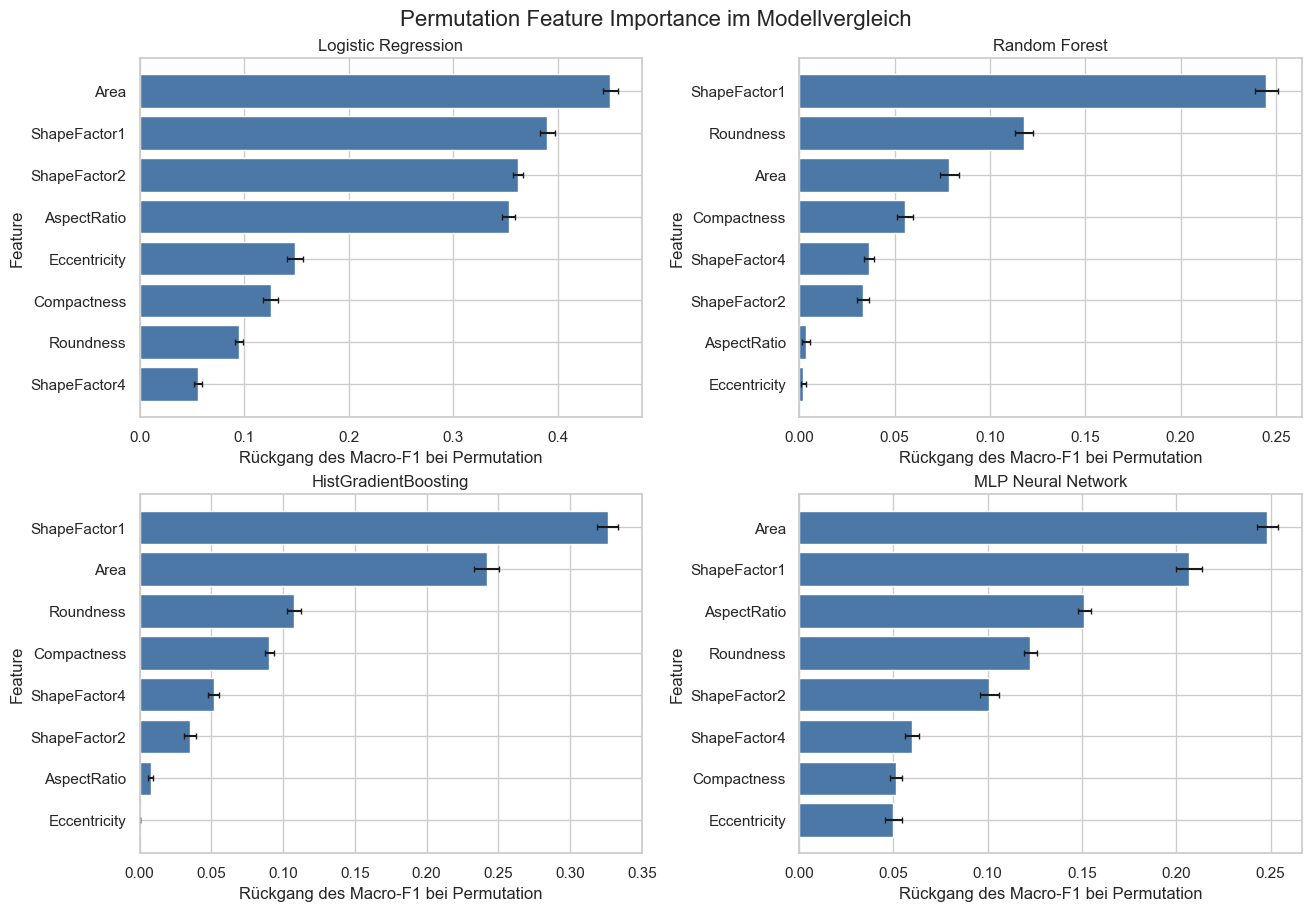

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, name in zip(axes.ravel(), MODEL_ORDER):
    plot_data = pfi_df.query('model == @name').sort_values('importance_mean')
    ax.barh(
        plot_data['feature'],
        plot_data['importance_mean'],
        xerr=plot_data['importance_std'],
        color='#4c78a8',
        capsize=2,
    )
    ax.set_title(name)
    ax.set_xlabel('Rückgang des Macro-F1 bei Permutation')
    ax.set_ylabel('Feature')
fig.suptitle('Permutation Feature Importance im Modellvergleich', fontsize=16)
plt.show()


## Globale SHAP-Auswertung für alle Modelle

Die globale SHAP-Auswertung zeigt, welche Merkmale die Vorhersagen eines Modells besonders stark beeinflussen. Für die Baumverfahren wird TreeSHAP verwendet, für die logistische Regression LinearSHAP und für das MLP KernelSHAP.

Die Skalen unterscheiden sich je nach Modell. Verglichen werden deshalb die Rangfolgen innerhalb eines Modells und gemeinsame Muster zwischen den Modellen.

In [6]:
def normalise_shap_values(values, n_features, n_classes):
    if isinstance(values, list):
        values = np.stack(values, axis=-1)
    values = np.asarray(values)
    if values.ndim == 2:
        values = values[:, :, np.newaxis]
    if values.shape[1] == n_classes and values.shape[2] == n_features:
        values = np.moveaxis(values, 1, -1)
    assert values.shape[1] == n_features and values.shape[2] == n_classes, values.shape
    return values

def dataframe_predict_proba(model):
    return lambda array: model.predict_proba(pd.DataFrame(array, columns=selected_features))

X_shap = X_test.sample(n=500, random_state=RANDOM_STATE)
X_mlp_shap = X_test.sample(n=100, random_state=RANDOM_STATE)
X_mlp_background = X_train.sample(n=50, random_state=RANDOM_STATE)
shap_explainers, shap_values_by_model, shap_samples = {}, {}, {}

for name in ['Random Forest', 'HistGradientBoosting']:
    explainer = shap.TreeExplainer(fitted_models[name])
    values = normalise_shap_values(explainer.shap_values(X_shap), len(selected_features), len(fitted_models[name].classes_))
    shap_explainers[name], shap_values_by_model[name], shap_samples[name] = explainer, values, X_shap

logistic_pipeline = fitted_models['Logistic Regression']
logistic_scaler = logistic_pipeline.named_steps['scaler']
logistic_model = logistic_pipeline.named_steps['model']
linear_explainer = shap.LinearExplainer(logistic_model, logistic_scaler.transform(X_train))
linear_values = normalise_shap_values(linear_explainer.shap_values(logistic_scaler.transform(X_shap)), len(selected_features), len(logistic_model.classes_))
shap_explainers['Logistic Regression'], shap_values_by_model['Logistic Regression'], shap_samples['Logistic Regression'] = linear_explainer, linear_values, X_shap

mlp_pipeline = fitted_models['MLP Neural Network']
kernel_explainer = shap.KernelExplainer(dataframe_predict_proba(mlp_pipeline), X_mlp_background)
kernel_values = normalise_shap_values(kernel_explainer.shap_values(X_mlp_shap, nsamples=128, silent=True), len(selected_features), len(mlp_pipeline.classes_))
shap_explainers['MLP Neural Network'], shap_values_by_model['MLP Neural Network'], shap_samples['MLP Neural Network'] = kernel_explainer, kernel_values, X_mlp_shap

shap_rows = []
for name in MODEL_ORDER:
    global_values = np.abs(shap_values_by_model[name]).mean(axis=(0, 2))
    shap_rows.extend({'model': name, 'feature': feature, 'mean_abs_shap': value} for feature, value in zip(selected_features, global_values))
shap_df = pd.DataFrame(shap_rows)
shap_rankings = shap_df.sort_values(['model', 'mean_abs_shap'], ascending=[True, False]).groupby('model', group_keys=False).head(4)
shap_rankings[['model', 'feature', 'mean_abs_shap']].sort_values(['model', 'mean_abs_shap'], ascending=[True, False])


,model,feature,mean_abs_shap
16,HistGradientBoosting,Area,1.141000
21,HistGradientBoosting,ShapeFactor1,0.814018
19,HistGradientBoosting,Compactness,0.475464
20,HistGradientBoosting,Roundness,0.346423
0,Logistic Regression,Area,5.487918
5,Logistic Regression,ShapeFactor1,3.834332
6,Logistic Regression,ShapeFactor2,3.438121
1,Logistic Regression,AspectRatio,3.379325
29,MLP Neural Network,ShapeFactor1,0.081431
24,MLP Neural Network,Area,0.065690


Die globale SHAP-Grafik zeigt die mittleren absoluten Beiträge der Merkmale innerhalb des jeweiligen Modells.

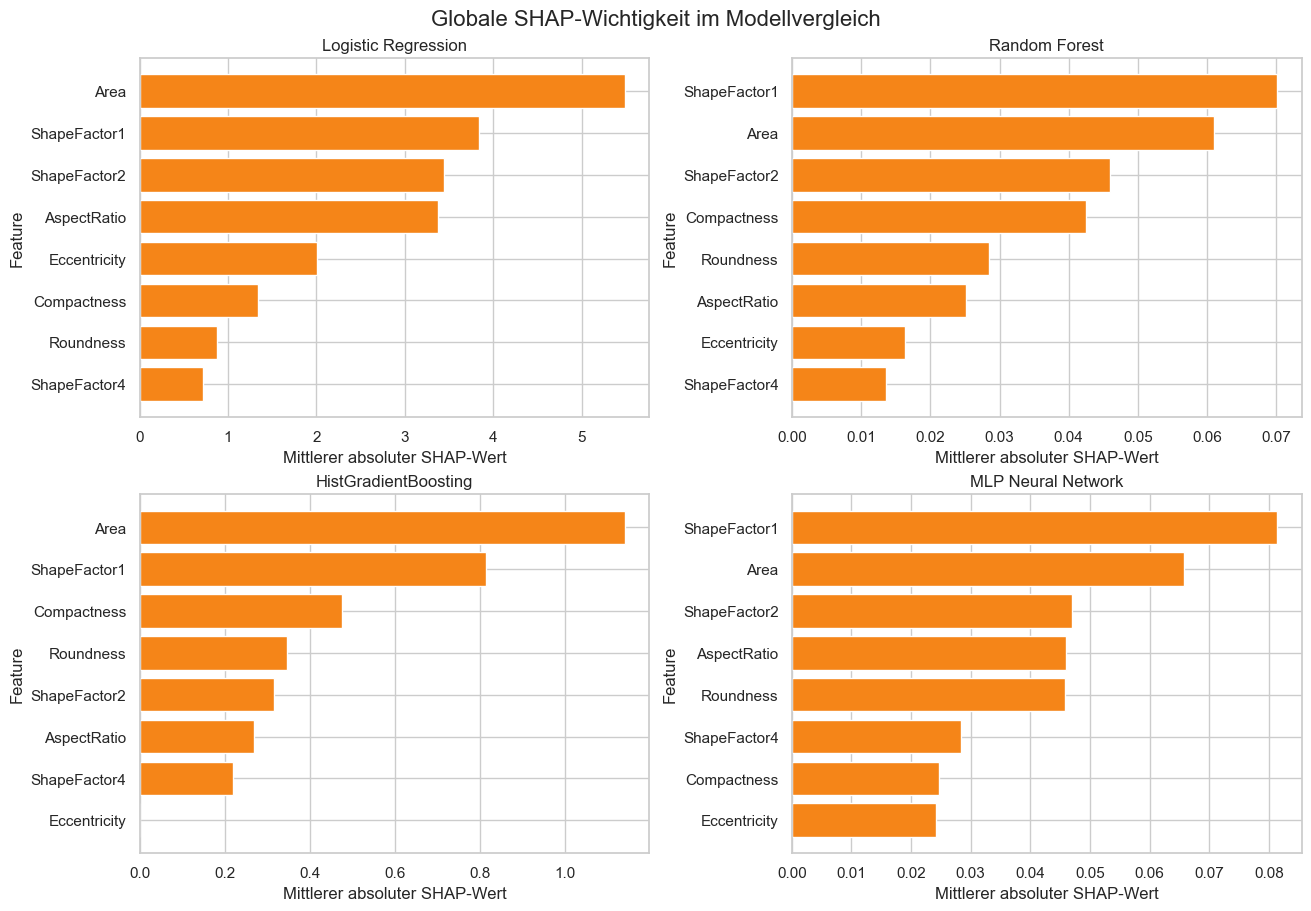

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, name in zip(axes.ravel(), MODEL_ORDER):
    plot_data = shap_df[shap_df['model'] == name].sort_values('mean_abs_shap')
    ax.barh(plot_data['feature'], plot_data['mean_abs_shap'], color='#f58518')
    ax.set_title(name)
    ax.set_xlabel('Mittlerer absoluter SHAP-Wert')
    ax.set_ylabel('Feature')
fig.suptitle('Globale SHAP-Wichtigkeit im Modellvergleich', fontsize=16)
plt.show()


## Lokale Fälle mit SHAP und LIME

SHAP und LIME erklären eine korrekt klassifizierte DERMASON-Instanz sowie einen Fehlfall. Die Erklärung bezieht sich jeweils auf die vorhergesagte Klasse.

In [8]:
y_test_array = y_test.to_numpy()
all_correct = np.logical_and.reduce([predictions[name] == y_test_array for name in MODEL_ORDER])
shared_correct_positions = np.flatnonzero((y_test_array == 'DERMASON') & all_correct)
if len(shared_correct_positions) == 0:
    raise ValueError('Keine gemeinsam korrekt klassifizierte DERMASON-Instanz gefunden.')
correct_position = int(shared_correct_positions[0])

preferred_pairs = [('DERMASON', 'SIRA'), ('SIRA', 'DERMASON'), ('BARBUNYA', 'CALI'), ('CALI', 'BARBUNYA')]
local_cases = {}
for name in MODEL_ORDER:
    y_pred = predictions[name]
    selected_position, selection_note = None, None
    for actual, predicted in preferred_pairs:
        positions = np.flatnonzero((y_test_array == actual) & (y_pred == predicted))
        if len(positions):
            selected_position, selection_note = int(positions[0]), f'bevorzugtes Fehlmuster {actual} als {predicted}'
            break
    if selected_position is None:
        positions = np.flatnonzero(y_pred != y_test_array)
        selected_position, selection_note = int(positions[0]), 'erster vorhandener Fehlfall'
    local_cases[name] = {'correct': correct_position, 'misclassified': selected_position, 'selection_note': selection_note}

case_table = pd.DataFrame([{'model': name, 'korrekt_true': y_test.iloc[correct_position], 'korrekt_pred': predictions[name][correct_position], 'fehler_true': y_test.iloc[data['misclassified']], 'fehler_pred': predictions[name][data['misclassified']], 'fehlerauswahl': data['selection_note']} for name, data in local_cases.items()])
case_table


,model,korrekt_true,korrekt_pred,fehler_true,fehler_pred,fehlerauswahl
0,Logistic Regression,DERMASON,DERMASON,DERMASON,SIRA,bevorzugtes Fehlmuster DERMASON als SIRA
1,Random Forest,DERMASON,DERMASON,DERMASON,SIRA,bevorzugtes Fehlmuster DERMASON als SIRA
2,HistGradientBoosting,DERMASON,DERMASON,DERMASON,SIRA,bevorzugtes Fehlmuster DERMASON als SIRA
3,MLP Neural Network,DERMASON,DERMASON,DERMASON,SIRA,bevorzugtes Fehlmuster DERMASON als SIRA


Die lokale SHAP-Auswertung zeigt, welche Merkmale die jeweilige Vorhersage stützen oder abschwächen.

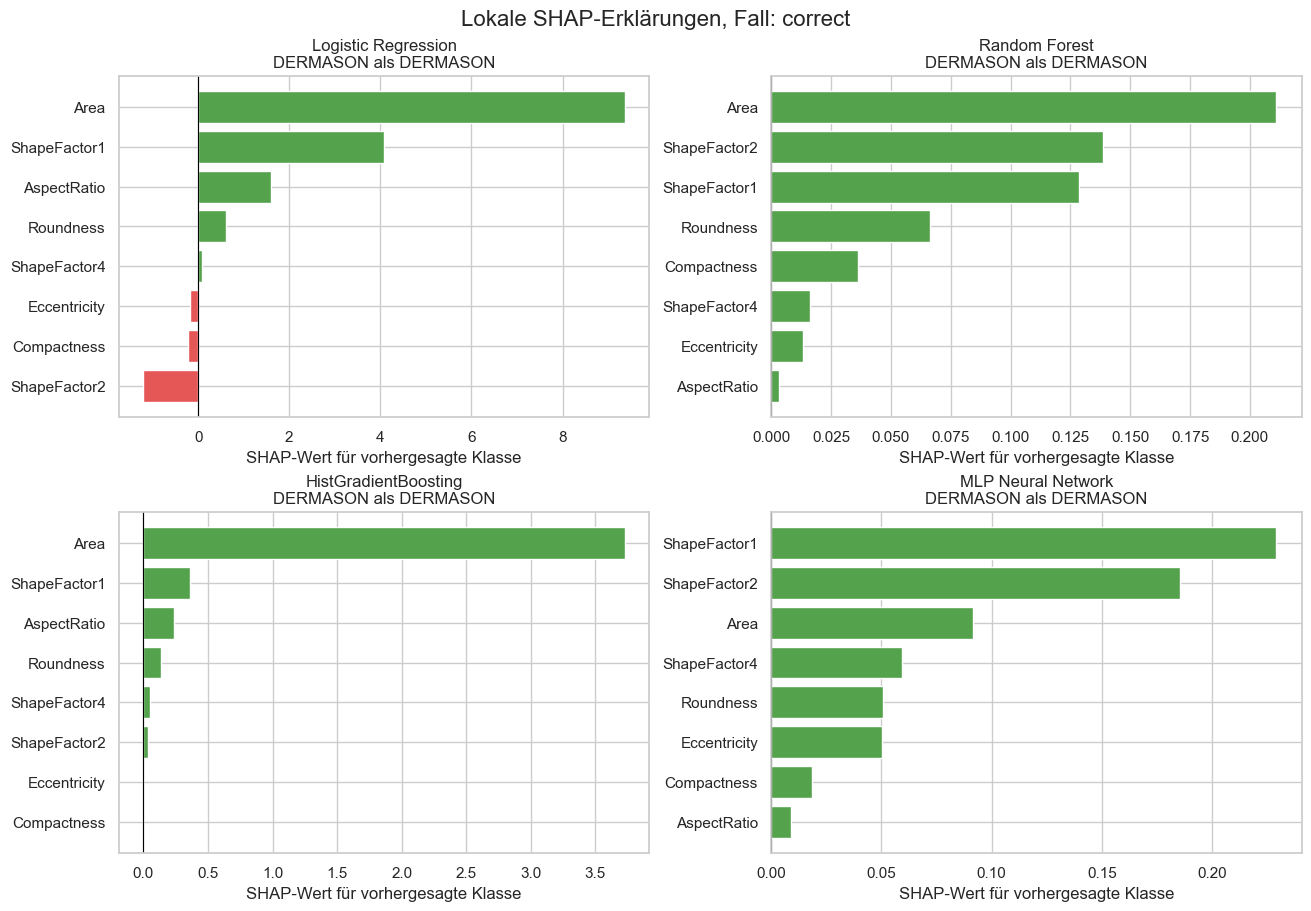

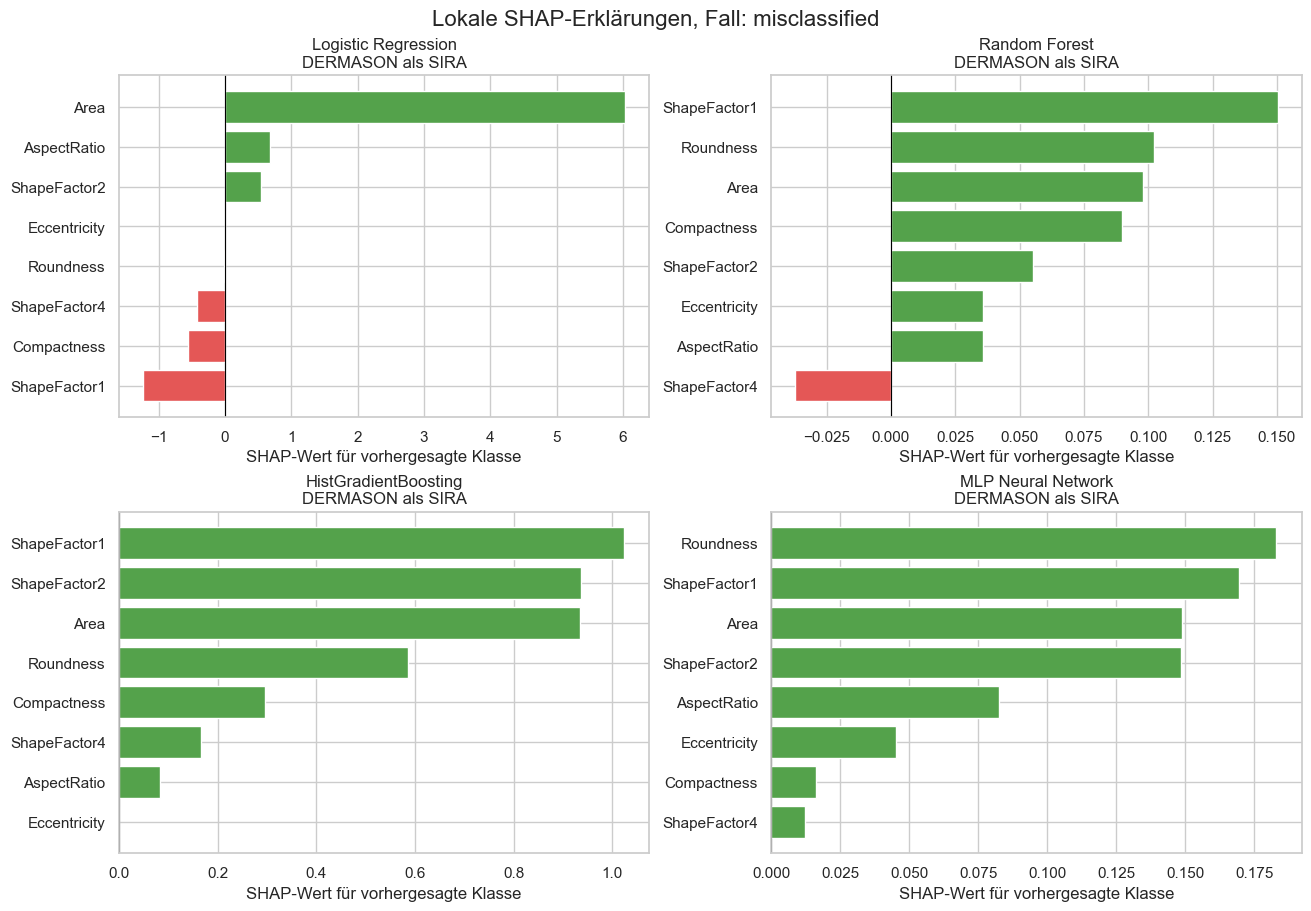

In [9]:
def local_shap_values(name, position):
    model = fitted_models[name]
    observation = X_test.iloc[[position]]
    if name in ['Random Forest', 'HistGradientBoosting']:
        raw_values = shap_explainers[name].shap_values(observation)
    elif name == 'Logistic Regression':
        raw_values = shap_explainers[name].shap_values(logistic_scaler.transform(observation))
    else:
        raw_values = shap_explainers[name].shap_values(observation, nsamples=128, silent=True)
    values = normalise_shap_values(raw_values, len(selected_features), len(model.classes_))
    predicted = predictions[name][position]
    class_index = list(model.classes_).index(predicted)
    return pd.DataFrame({'feature': selected_features, 'value': observation.iloc[0].to_numpy(), 'shap_value': values[0, :, class_index]}), predicted

def local_lime_values(name, position, class_index):
    model = fitted_models[name]
    lime_explainer = LimeTabularExplainer(training_data=X_train.to_numpy(), feature_names=selected_features, class_names=list(model.classes_), mode='classification', discretize_continuous=True, random_state=RANDOM_STATE)
    explanation = lime_explainer.explain_instance(X_test.iloc[position].to_numpy(), dataframe_predict_proba(model), labels=[class_index], num_features=len(selected_features))
    return pd.DataFrame(explanation.as_list(label=class_index), columns=['condition', 'lime_weight'])

def plot_local_shap(case_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    rows = []
    for ax, name in zip(axes.ravel(), MODEL_ORDER):
        position = local_cases[name][case_name]
        local_df, predicted = local_shap_values(name, position)
        actual = y_test.iloc[position]
        plot_data = local_df.sort_values('shap_value')
        ax.barh(plot_data['feature'], plot_data['shap_value'], color=np.where(plot_data['shap_value'] >= 0, '#54a24b', '#e45756'))
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{name}\n{actual} als {predicted}')
        ax.set_xlabel('SHAP-Wert für vorhergesagte Klasse')
        rows.extend({'model': name, 'case': case_name, 'actual': actual, 'predicted': predicted, 'feature': row.feature, 'shap_value': row.shap_value} for row in local_df.itertuples())
    fig.suptitle(f'Lokale SHAP-Erklärungen, Fall: {case_name}', fontsize=16)
    plt.show()
    return pd.DataFrame(rows)

local_shap_correct = plot_local_shap('correct', 'SHAP_Lokal_Korrekt_Alle_Modelle.pdf')
local_shap_misclassified = plot_local_shap('misclassified', 'SHAP_Lokal_Fehlklassifikation_Alle_Modelle.pdf')


LIME ergänzt die lokalen SHAP-Erklärungen für dieselben Fälle.

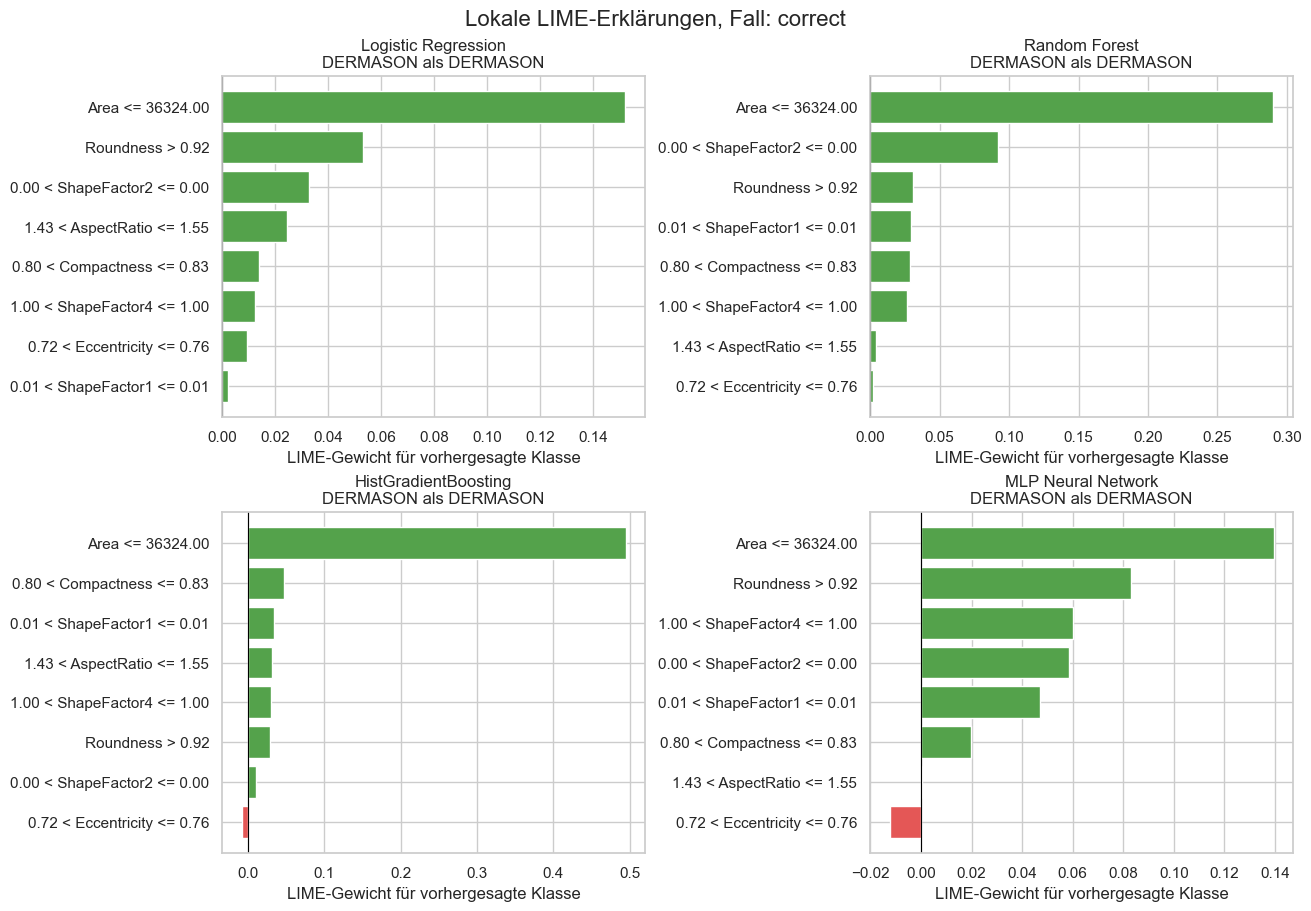

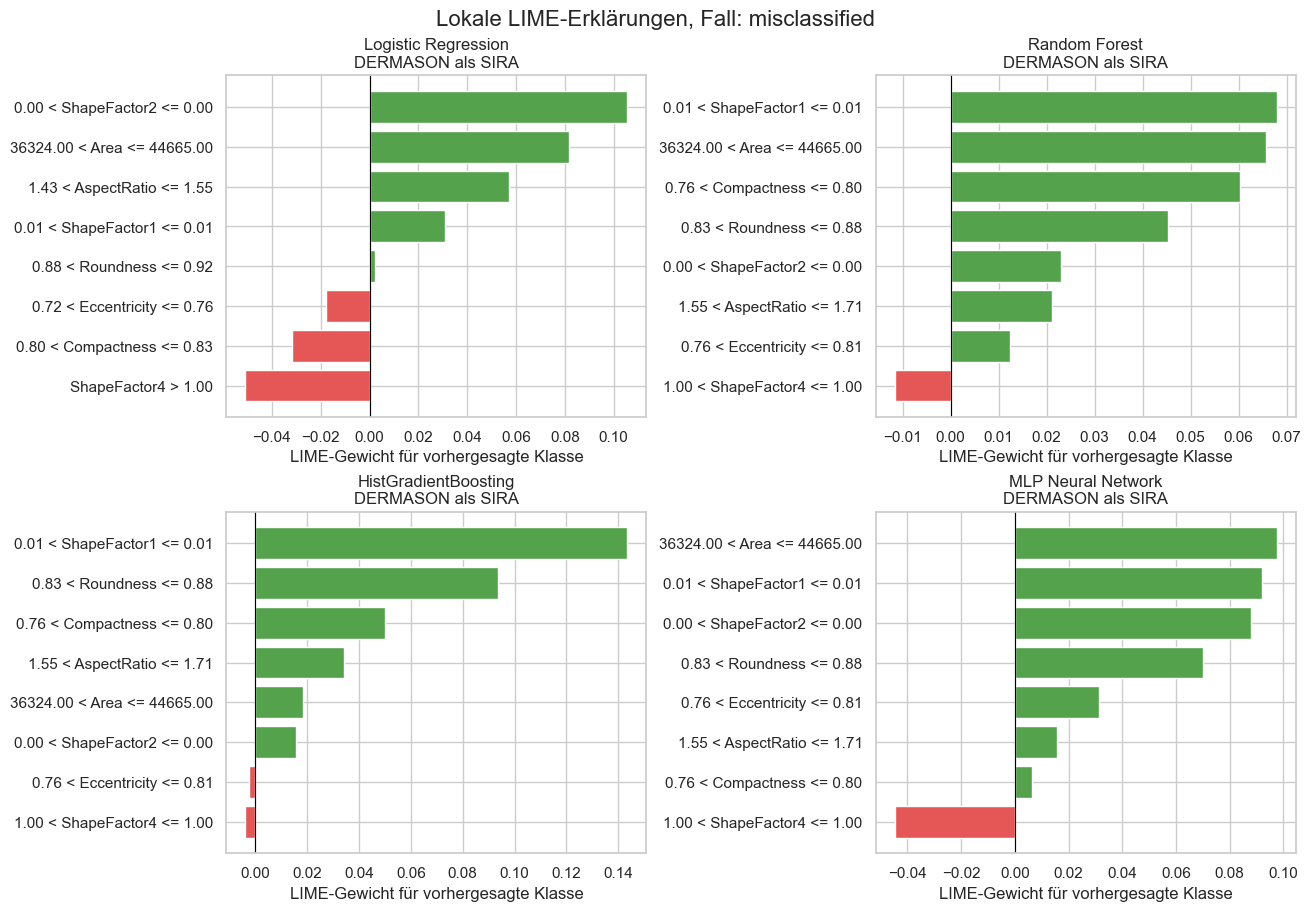

In [10]:
def plot_local_lime(case_name, filename):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    rows = []
    for ax, name in zip(axes.ravel(), MODEL_ORDER):
        position = local_cases[name][case_name]
        predicted = predictions[name][position]
        actual = y_test.iloc[position]
        class_index = list(fitted_models[name].classes_).index(predicted)
        local_df = local_lime_values(name, position, class_index)
        plot_data = local_df.sort_values('lime_weight')
        ax.barh(plot_data['condition'], plot_data['lime_weight'], color=np.where(plot_data['lime_weight'] >= 0, '#54a24b', '#e45756'))
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{name}\n{actual} als {predicted}')
        ax.set_xlabel('LIME-Gewicht für vorhergesagte Klasse')
        rows.extend({'model': name, 'case': case_name, 'actual': actual, 'predicted': predicted, 'condition': row.condition, 'lime_weight': row.lime_weight} for row in local_df.itertuples())
    fig.suptitle(f'Lokale LIME-Erklärungen, Fall: {case_name}', fontsize=16)
    plt.show()
    return pd.DataFrame(rows)

local_lime_correct = plot_local_lime('correct', 'LIME_Lokal_Korrekt_Alle_Modelle.pdf')
local_lime_misclassified = plot_local_lime('misclassified', 'LIME_Lokal_Fehlklassifikation_Alle_Modelle.pdf')
